# Week 7 - Temporal models 

## Part 3: Road traffic - Multi-variate time-series forecasting

In this part, we will specify a **multivariate** linear dynamical system (LDS) in Pyro in order to forecast freeway occupancy rates. 

The usual imports...

In [7]:
# Install Pyro, if necessary
!pip install pyro-ppl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import math
import torch
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.contrib.examples.bart import load_bart_od
from pyro.contrib.forecast import ForecastingModel, Forecaster, eval_crps
from pyro.infer.reparam import LinearHMMReparam, StableReparam, SymmetricStableReparam
from pyro.ops.tensor_utils import periodic_repeat
from pyro.ops.stats import quantile
import matplotlib.pyplot as plt

import time

# fix MCMCndom generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib style options
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

The data consists of time-series of freeway occupancy rates (rows), with length $T=1008$, at 10 different consecutive sensors/detectors (columns). However, for now, we will focus only on the data from a single detector as an example...

Load data:

In [9]:
df = pd.read_csv("http://mlsm.man.dtu.dk/mbml/PeMS_sample.csv")
df.head()

URLError: <urlopen error [Errno 61] Connection refused>

Some basic data statistics:

In [ ]:
print("Dataset size:", len(df))
print("General statistics:")
df.describe()

Dataset size: 1008
General statistics:


,# detector400000,detector400001,detector400009,detector400010,detector400015,detector400017,detector400025,detector400026,detector400027,detector400030
count,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.00000,1008.000000
mean,0.049489,0.044541,0.066207,0.051599,0.026812,0.047976,0.037051,0.055881,0.05583,0.049262
std,0.030016,0.047490,0.047321,0.040934,0.019402,0.052455,0.036248,0.049275,0.04192,0.042152
min,0.005300,0.000000,0.000000,0.000000,0.001900,0.002200,0.002900,0.002500,0.00150,0.001500
25%,0.027150,0.014900,0.029525,0.018000,0.013100,0.014775,0.012075,0.017950,0.01820,0.027075
50%,0.055300,0.038600,0.070500,0.046400,0.021700,0.038750,0.029000,0.051500,0.05665,0.046700
75%,0.064400,0.051900,0.088025,0.070800,0.030925,0.054125,0.045400,0.069825,0.07670,0.058925
max,0.317600,0.355000,0.393600,0.232700,0.094900,0.316900,0.197200,0.307400,0.22060,0.408100


Visualize data (part of it):

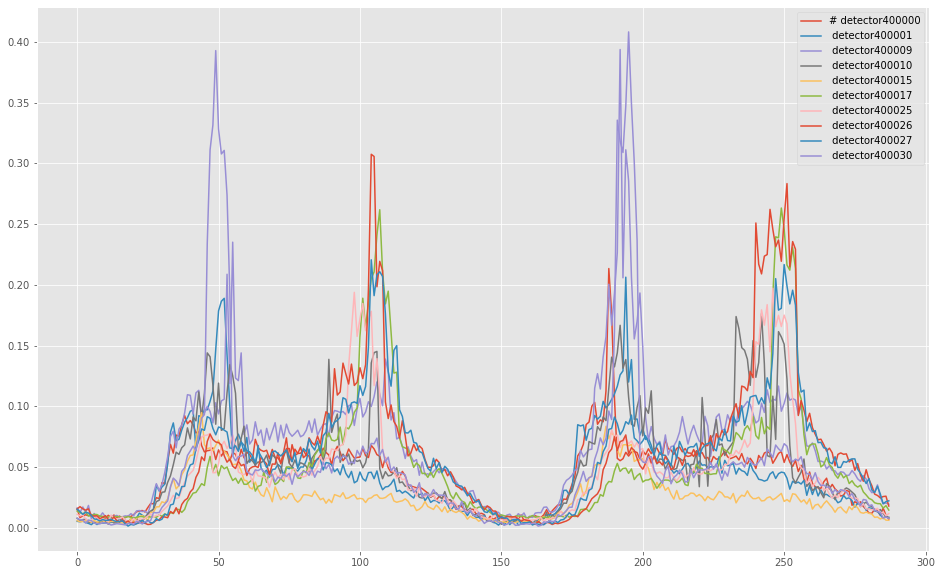

In [ ]:
plt.plot(df[:(2*24*6)]); # first 2 days (2*24*6 10-minute intervals) of each of the 10 detectors
plt.legend(df.columns);

Split data into a trainset and a testset (which we wish to forecast):

In [ ]:
# convert data to a matrix
y = df.values
N, D = y.shape
print("N=%d, D=%d" % (N,D))

T0 = 0
T1 = 6*24*6
T2 = 6*24*6 + 12
ix_train = range(T0, T1)
ix_test = range(T1, T2)
N_train = len(ix_train)
N_test = len(ix_test)
print("N_train:", N_train)
print("N_test:", N_test)
y = torch.tensor(y).float()

N=1008, D=10
N_train: 864
N_test: 12


Note that the split is the same as in the previous notebook, but now our training data will include more that one time-series. We will **start by considering the first two time-series:** ``y[T0:T1,:2]``. However, we will still evaluate the performance on the test data from the first time-series as before (``y[T1:T2,:1]``). The intution is that by jointly modelling the two time-series, since they are highly correlated, the model can leverage those correlations to better prediction the first time-series. 

We start by computing the now **two-dimensional** historical average pattern (one for each time-series):

In [ ]:
historical_average = y[T0:T1 // (24*6) * 24*6,:2].reshape(-1, 24*6, 2).mean(0) # this how an average day in the training data looks like
#historical_average = torch.zeros_like(historical_average) # in case you want to try removing the historical average component from the model used this line instead
historical_average_std = y[T0:T1 // (24*6) * 24*6,:2].reshape(-1, 24*6, 2).std(0) # we can also compute the standard deviation of the historical average...

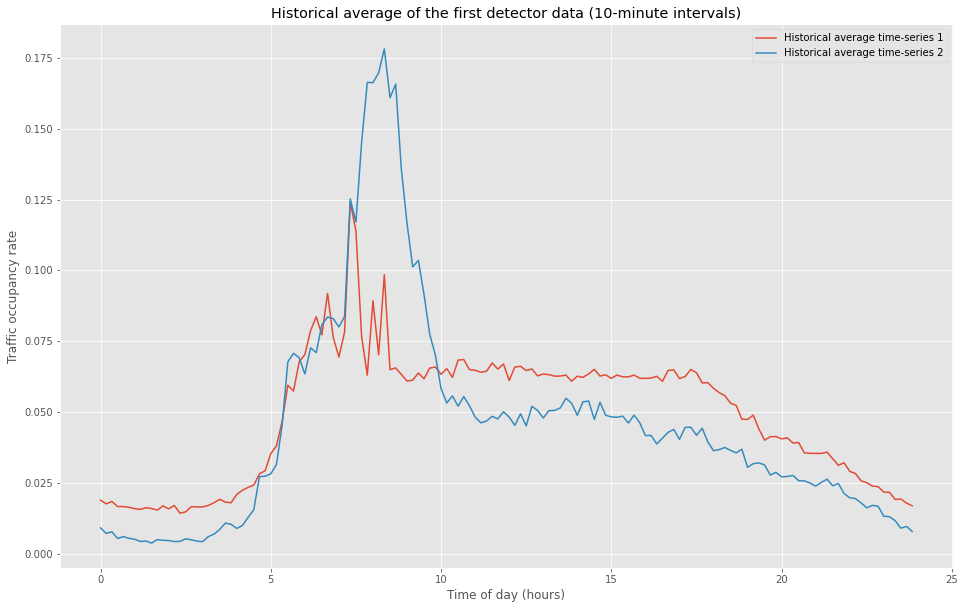

In [ ]:
plt.plot(np.arange(0,24,1/6), historical_average);
plt.title("Historical average of the first detector data (10-minute intervals)")
plt.xlabel("Time of day (hours)");
plt.ylabel("Traffic occupancy rate");
plt.legend(["Historical average time-series 1", "Historical average time-series 2"]);

Now it is time to implement the multivariate model in Pyro. The generative process is similar to the ones from the previous notebook, but now the hidden states $\textbf{z}_t$ and the observations $y_t$ are 2-dimensional:

\begin{align}
\textbf{z}_t &\sim \mathcal{N}(\textbf{B} \textbf{z}_{t-1}, \tau^2)\\
\textbf{y}_t &\sim \mathcal{N}(\textbf{z}_t + \textbf{h}_t, \sigma^2)
\end{align}

Note that the transition matrix $\textbf{B}$ is now a 2x2 matrix. 

Can you try to implement the multivariate model in Pyro yourself? HINT: you can just adapt the univariate model implementations from the previous notebook.

In [ ]:
class Model3(ForecastingModel):
    def model(self, zero_data, covariates):
        duration = zero_data.size(-2)
        
        mean_prediction = torch.zeros(zero_data.shape) # in this version of the model, the mean prediction is just zero - i.e., no periodic component
        
        # On top of this mean prediction, we'll learn a linear dynamical system.
        # This requires specifying five pieces of data, on which we will put structured priors.
        init_dist = dist.Normal(torch.zeros(2),  torch.ones(2)).to_event(1) 

        trans_matrix = pyro.sample("timescale", dist.Normal(torch.ones(2,2), torch.ones(2)).to_event(2))
        trans_scale = pyro.sample("trans_scale", dist.HalfNormal(torch.ones(2)).to_event(1)) 
        trans_dist = dist.Normal(torch.zeros(2), trans_scale).to_event(1)

        # Note the obs_matrix has shape hidden_dim x obs_dim = 1 x 1.
        obs_matrix = torch.eye(1)
        obs_scale = pyro.sample("obs_scale", dist.HalfNormal(torch.ones(2)).to_event(1)) 
        obs_dist = dist.Normal(torch.zeros(2), obs_scale).to_event(1)

        noise_dist = dist.GaussianHMM(init_dist, trans_matrix, trans_dist, obs_matrix, obs_dist, duration=duration)
        self.predict(noise_dist, mean_prediction)
        


And we now perform Bayesian inference on this new version of the model. Note that the input for the ``Forecaster`` object is now ``y[T0:T1,:2]`` - a bi-variate time-series.

In [ ]:
%%time
pyro.set_rng_seed(1)
pyro.clear_param_store()
covariates = torch.zeros(T1-T0, 0)  # empty
forecaster = Forecaster(Model3(), y[T0:T1,:2], covariates, learning_rate=0.1, num_steps=500)
for name, value in forecaster.guide.median().items():
    if value.numel() == 1:
        print("{} = {:0.4g}".format(name, value.item()))

INFO 	 step    0 loss = 1.21403
INFO 	 step  100 loss = -2.89146
INFO 	 step  200 loss = -2.89874
INFO 	 step  300 loss = -2.90387
INFO 	 step  400 loss = -2.90748


CPU times: user 5.31 s, sys: 2.15 s, total: 7.46 s
Wall time: 5.81 s


And evaluate the results (as we did before for Model 1). Crucially, note that we still evaluate the performance on the test data from the first time-series as before (``y[T1:T2,:1]``). Again, the intution is that by jointly modelling the two time-series, since they are highly correlated, the model can leverage those correlations to better prediction the first time-series. 

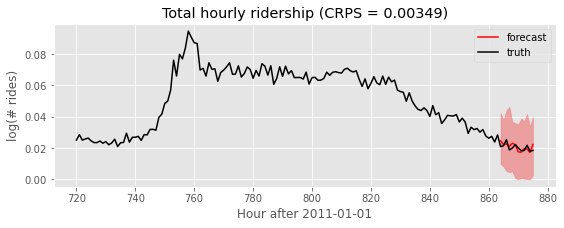

In [ ]:
covariates_with_test = torch.zeros(T2-T0, 0)  # empty
samples = forecaster(y[T0:T1,:2], covariates_with_test, num_samples=100)
samples.clamp_(min=0)  # apply domain knowledge: the samples must be positive
p10, p50, p90 = quantile(samples[...,:1], (0.1, 0.5, 0.9)).squeeze(-1)
crps = eval_crps(samples[...,:1], y[T1:T2,:1])

plt.figure(figsize=(9, 3))
plt.fill_between(torch.arange(T1, T2), p10, p90, color="red", alpha=0.3)
plt.plot(torch.arange(T1, T2), p50, 'r-', label='forecast')
plt.plot(torch.arange(T1-24*6, T2), y[T1-24*6:T2,:1], 'k-', label='truth')
plt.title("Total hourly ridership (CRPS = {:0.3g})".format(crps))
plt.ylabel("log(# rides)")
plt.xlabel("Hour after 2011-01-01")
plt.legend(loc="best");

Did it work? Did it improve? Probably not by much - the improvement that one could expect can depend on a lot of factors and characteristics of the application (e.g., how strong the correlation between the time-series is). Nevertheless, you are now able to implement multi-variate time-series models in Pyro. Think of all the possible applications and variants of these models that could implement!

**Reflection:**
- How could you modify the model above to take into account (time-dependent) covariates. What if you wanted to make the mean prediction ($\textbf{h}_t$) a non-linear function of the covariates using, for example, a neural network. How would the generative model change? How would you implement that in Pyro? 
- What if you wanted to make the state-transition to be themselves non-linear function (i.e., the hidden state at time t is a non-linear function of the previous state at time t-1) using a neural network? Pyro actually has a cool example of such a model - see [Deep Markov Model](https://pyro.ai/examples/dmm.html). 

**Further reading:**
- Check out also the Pyro example on [Multivariate Forecasting](https://pyro.ai/examples/forecast_simple.html). 